In [12]:
import tensorflow as tf
print(tf.__version__) #checking tensorflow version
gpus = tf.config.list_physical_devices('GPU')
print("Num GPUs Available: ", len(gpus)) # check if the GPU is available

if gpus:
    print("GPU Details:", gpus)
else:
    print("No GPU detected. TensorFlow is running on CPU.")

2.20.0
Num GPUs Available:  1
GPU Details: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [13]:
""""external libaries import configuration"""
import tensorflow as tf
from tensorflow import keras # type: ignore
from tensorflow.keras import layers  # type: ignore

import numpy as np
import matplotlib.pyplot as plt

import os
import pathlib

In [14]:
img_size = (160,160) # All images will be resized to 160x160
batch_size = 32
SEED = 42  # MUST be identical for both subsets — this is what makes the split disjoint

# train and val are carved out of the same directory, so they share validation_split + seed
train_ds = tf.keras.utils.image_dataset_from_directory(
    'data/train',  # This is the target directory
    validation_split=0.1,
    subset="training",
    seed=SEED,
    image_size=img_size,
    batch_size=batch_size,
    label_mode='binary'
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    "data/train",
    validation_split=0.1,
    subset="validation",
    seed=SEED,
    image_size=img_size,
    batch_size=batch_size,
    label_mode="binary"
)
test_ds = tf.keras.utils.image_dataset_from_directory(
    "data/test",
    image_size=img_size,
    batch_size=batch_size,
    label_mode="binary",
    shuffle=False
)

# guard against the split silently regressing (e.g. mismatched seeds)
overlap = set(train_ds.file_paths) & set(val_ds.file_paths)
assert not overlap, f"train/val leakage: {len(overlap)} shared images"
print(f"train: {len(train_ds.file_paths)}  val: {len(val_ds.file_paths)}  test: {len(test_ds.file_paths)}")

class_names = train_ds.class_names
print(class_names)  # ['cat', 'dog']

Found 800 files belonging to 2 classes.
Using 720 files for training.
Found 800 files belonging to 2 classes.
Using 80 files for validation.
Found 200 files belonging to 2 classes.
train: 720  val: 80  test: 200
['cat', 'dog']


2026-08-03 22:33:26.119297: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


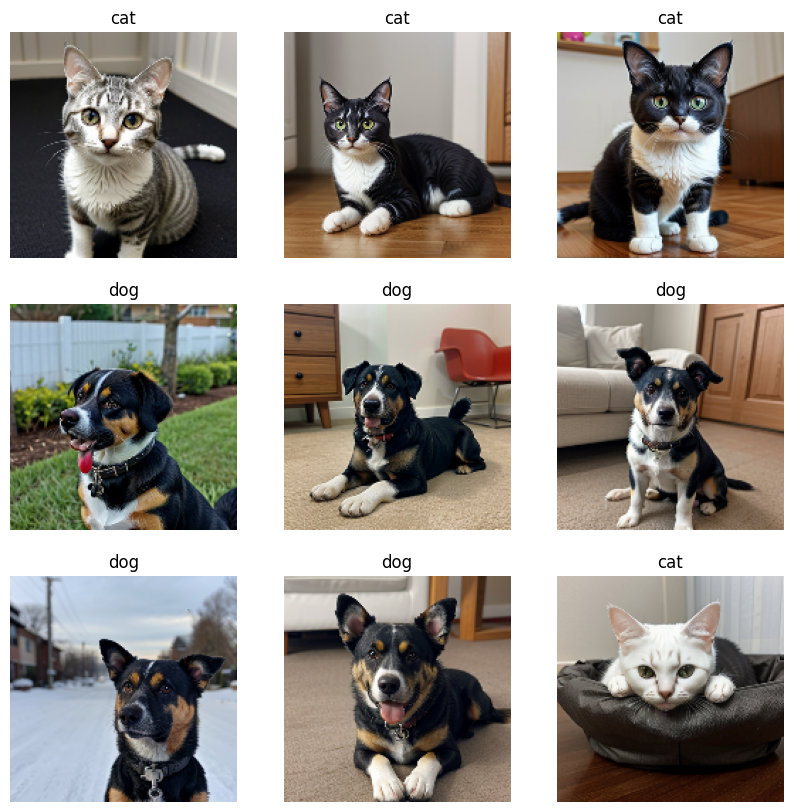

In [15]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1): #Grabs only the first batch 
                                       # from the dataset. If your batch size is 32, this single step pulls 32 images and 32 labels.
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[int(labels[i])])
        plt.axis("off")

In [16]:
# Apply ResNetV2 preprocessing (scales to [-1, 1])
# NOTE: this rebinds the dataset names in place, so cell 2 must be re-run
# before re-running this cell (otherwise preprocessing gets applied twice).
from tensorflow.keras.applications.resnet_v2 import preprocess_input

train_ds = train_ds.map(lambda x, y: (preprocess_input(x), y))
val_ds   = val_ds.map(lambda x, y: (preprocess_input(x), y))
test_ds  = test_ds.map(lambda x, y: (preprocess_input(x), y))   # was missing — test stayed at 0-255

In [17]:
Autotune = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=Autotune)
test_ds = test_ds.cache().prefetch(buffer_size=Autotune)
val_ds = val_ds.cache().prefetch(buffer_size=Autotune)

In [18]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

In [19]:
from tensorflow.keras.applications import ResNet152V2

base_model = ResNet152V2(
    input_shape=img_size + (3,),
    include_top=False,
    weights="imagenet"
)
base_model.trainable = False

In [20]:
inputs = tf.keras.Input(shape=img_size + (3,))
x = data_augmentation(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet152v2 (Functional)        │ (None, 5, 5, 2048)     │    58,331,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         2,049 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 58,333,697 (222.53 MB)

 Trainable params: 2,049 (8.00 KB)

 Non-trainable params: 58,331,648 (222.52 MB)

In [21]:
EPOCHS = 30
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    
)

Epoch 1/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 19s 269ms/step - accuracy: 0.8014 - loss: 0.4529 - val_accuracy: 0.9375 - val_loss: 0.1812
Epoch 2/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 109ms/step - accuracy: 0.8708 - loss: 0.2955 - val_accuracy: 0.9875 - val_loss: 0.0992
Epoch 3/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 105ms/step - accuracy: 0.9111 - loss: 0.2199 - val_accuracy: 1.0000 - val_loss: 0.0620
Epoch 4/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 113ms/step - accuracy: 0.9472 - loss: 0.1425 - val_accuracy: 1.0000 - val_loss: 0.0441
Epoch 5/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 114ms/step - accuracy: 0.9611 - loss: 0.1111 - val_accuracy: 1.0000 - val_loss: 0.0343
Epoch 6/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 113ms/step - accuracy: 0.9847 - loss: 0.0800 - val_accuracy: 1.0000 - val_loss: 0.0277
Epoch 7/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 112ms/step - accuracy: 0.9722 - loss: 0.0785 - val_accuracy: 1.0000 - val_loss: 0.0228
Epoch 8/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 116ms/step - accuracy: 0.9667 - loss: 0.0968 - val_accuracy: 1

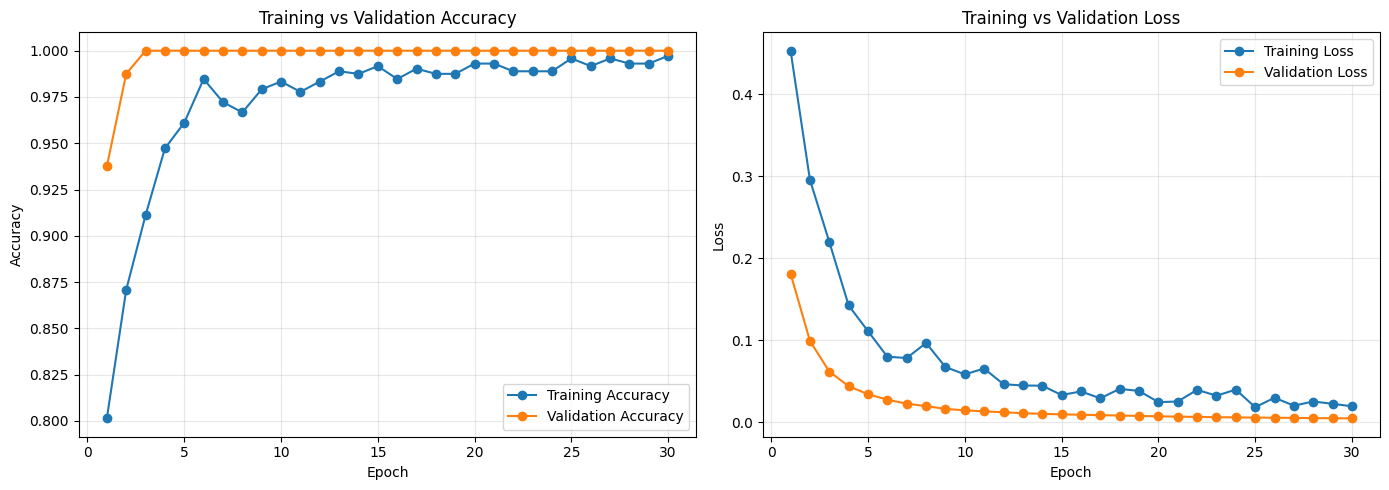

Final training accuracy:   0.9972
Final validation accuracy: 1.0000
Accuracy gap: -0.0028
Gap is small — generalizing reasonably well


In [22]:
import matplotlib.pyplot as plt

acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]

epochs_range = range(1, len(acc) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
axes[0].plot(epochs_range, acc, label="Training Accuracy", marker="o")
axes[0].plot(epochs_range, val_acc, label="Validation Accuracy", marker="o")
axes[0].set_title("Training vs Validation Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Loss plot
axes[1].plot(epochs_range, loss, label="Training Loss", marker="o")
axes[1].plot(epochs_range, val_loss, label="Validation Loss", marker="o")
axes[1].set_title("Training vs Validation Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Quantify the gap
final_train_acc = acc[-1]
final_val_acc = val_acc[-1]
gap = final_train_acc - final_val_acc
print(f"Final training accuracy:   {final_train_acc:.4f}")
print(f"Final validation accuracy: {final_val_acc:.4f}")
print(f"Accuracy gap: {gap:.4f}")

if gap > 0.10:
    print("⚠️ Significant gap — likely overfitting")
elif gap > 0.05:
    print("Mild gap — worth monitoring")
else:
    print("Gap is small — generalizing reasonably well")

## Test Evaluation

Held-out `data/test` (200 images), never seen during training or validation.

In [23]:
import numpy as np

# Run inference once; the ROC and metrics cells below both reuse these.
# test_ds was built with shuffle=False, so labels and predictions stay aligned.
y_true       = np.concatenate([y.numpy() for x, y in test_ds], axis=0).flatten()
y_pred_probs = model.predict(test_ds).flatten()
y_pred       = (y_pred_probs >= 0.5).astype(int)

print(f"test samples: {len(y_true)}  positives ({class_names[1]}): {int(y_true.sum())}")

7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 880ms/step
test samples: 200  positives (dog): 100


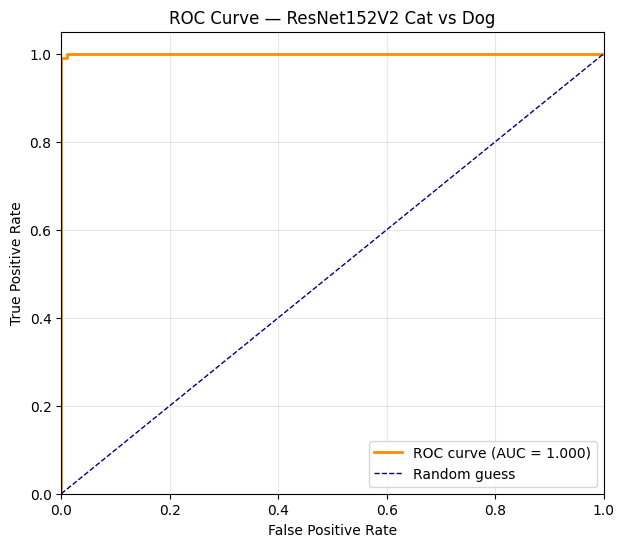

AUC Score: 0.9999


In [24]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_true, y_pred_probs)
roc_auc = auc(fpr, tpr)

# Plot
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], color="navy", lw=1, linestyle="--", label="Random guess")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — ResNet152V2 Cat vs Dog")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

print(f"AUC Score: {roc_auc:.4f}")

Accuracy:  0.9950
Precision: 1.0000
Recall:    0.9900
F1 Score:  0.9950


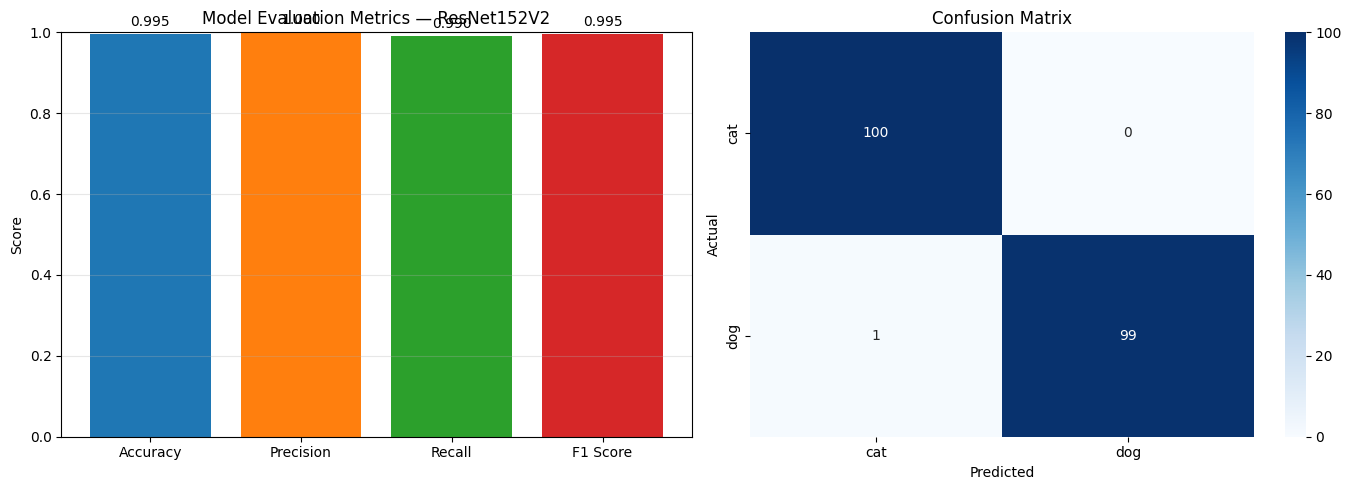

In [25]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Metrics
acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred)
rec  = recall_score(y_true, y_pred)
f1   = f1_score(y_true, y_pred)

print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1 Score:  {f1:.4f}")

# --- Plot 1: Metrics bar chart ---
metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]
values = [acc, prec, rec, f1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bars = axes[0].bar(metrics, values, color=["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"])
axes[0].set_ylim(0, 1.0)
axes[0].set_title("Model Evaluation Metrics — ResNet152V2")
axes[0].set_ylabel("Score")
axes[0].grid(axis="y", alpha=0.3)

for bar, val in zip(bars, values):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.02, f"{val:.3f}",
                 ha="center", fontsize=10)

# --- Plot 2: Confusion matrix heatmap ---
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")
axes[1].set_title("Confusion Matrix")

plt.tight_layout()
plt.show()